**Нейросетевая модель динамической системы**

$F(x_1, x_2) =
\begin {cases}
\dot{x}_1 = 5x_2 - 3x_1 ^ 3 \\
\dot{x}_2 = -x1 -2sin(x_2)
\end {cases}$

$N$ = 3

$L$ = 3

$\phi (s) = \begin{cases}
0, s < 0 \\
s, s \ge 0
\end{cases} (ReLU)
$

Импортируем библиотеки и задаем основные параметры модели

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

T = 0.01                    # Шаг по времени
N = 3                       # Количество будущих моментов времени
L = 3                       # Количество скрытых слоев
input_dim = 2               # Размерность входного вектора x = [x1, x2]
output_dim = input_dim * N  # Размер выходного слоя

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


Определяем функцию, описывающие систему дифференциальных уравнений

In [ ]:
def system_dynamics(t, x):
    x1, x2 = x

    dx1 = 5 * x2 - 3 * x1**3
    dx2 = -x1 - 2 * np.sin(x2)

    return [dx1, dx2]

Случайным образом генерируем начальные состояния системы в окрестности нуля, после чего с помощью метода solve_ivp вычисляются реальные траектории системы.

In [ ]:
def generate_dataset(num_samples=1000):

    x_train = []
    y_train = []

    # Моменты времени: T, 2T, ..., NT
    t_eval = [i * T for i in range(1, N + 1)]

    for _ in range(num_samples):

        # Случайное начальное состояние
        x_initial = np.random.uniform(-1, 1, size=(input_dim,))

        # Решение системы
        sol = solve_ivp(
            system_dynamics,
            [0, N * T],
            x_initial,
            t_eval=t_eval
        )

        if sol.status == 0:
            x_train.append(x_initial)
            y_train.append(sol.y.T.flatten())

    return (
        torch.tensor(np.array(x_train), dtype=torch.float32).to(device),
        torch.tensor(np.array(y_train), dtype=torch.float32).to(device)
    )

# Генерация датасета
x_data, y_data = generate_dataset(num_samples=2000)

print(f"Обучающая выборка: X = {x_data.shape}, Y = {y_data.shape}")

Обучающая выборка: X = torch.Size([2000, 2]), Y = torch.Size([2000, 6])


Создаем полносвязную нейронную сеть с:

* тремя скрытыми слоями;
* 64 нейронами в каждом скрытом слое;
* функцией активации ReLU.

In [ ]:
class DynamicSystemNet(nn.Module):

    def __init__(self, input_dim, output_dim, L):

        super(DynamicSystemNet, self).__init__()

        layers = []
        hidden_size = 64

        # Входной слой
        layers.append(nn.Linear(input_dim, hidden_size))
        layers.append(nn.ReLU())

        # Скрытые слои
        for _ in range(L-1):

            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # Выходной слой
        layers.append(nn.Linear(hidden_size, output_dim))

        # Последовательная модель
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Создаем модель
model = DynamicSystemNet(input_dim, output_dim, L).to(device)

print(model)

DynamicSystemNet(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=6, bias=True)
  )
)


Для обучения используем:

* функцию потерь MSELoss;
* оптимизатор Adam;
* 200 эпох обучения.

In [ ]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 200

loss_history = []

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(x_data)

    loss = criterion(y_pred, y_data)

    loss.backward()

    optimizer.step()

    current_loss = loss.item()

    loss_history.append(current_loss)

    if (epoch + 1) % 10 == 0:

        print(
            f'Эпоха [{epoch+1}/{epochs}], '
            f'Ошибка (Loss): {current_loss:.8f}'
        )

Эпоха [10/200], Ошибка (Loss): 0.26962212
Эпоха [20/200], Ошибка (Loss): 0.18875477
Эпоха [30/200], Ошибка (Loss): 0.08505782
Эпоха [40/200], Ошибка (Loss): 0.00985306
Эпоха [50/200], Ошибка (Loss): 0.00996896
Эпоха [60/200], Ошибка (Loss): 0.00234954
Эпоха [70/200], Ошибка (Loss): 0.00162948
Эпоха [80/200], Ошибка (Loss): 0.00112146
Эпоха [90/200], Ошибка (Loss): 0.00062076
Эпоха [100/200], Ошибка (Loss): 0.00046696
Эпоха [110/200], Ошибка (Loss): 0.00038176
Эпоха [120/200], Ошибка (Loss): 0.00030930
Эпоха [130/200], Ошибка (Loss): 0.00025196
Эпоха [140/200], Ошибка (Loss): 0.00020833
Эпоха [150/200], Ошибка (Loss): 0.00017439
Эпоха [160/200], Ошибка (Loss): 0.00014784
Эпоха [170/200], Ошибка (Loss): 0.00012669
Эпоха [180/200], Ошибка (Loss): 0.00010948
Эпоха [190/200], Ошибка (Loss): 0.00009547
Эпоха [200/200], Ошибка (Loss): 0.00008419


Построим график изменения ошибки в процессе обучения.

Для лучшей визуализации используем логарифмическую шкалу.

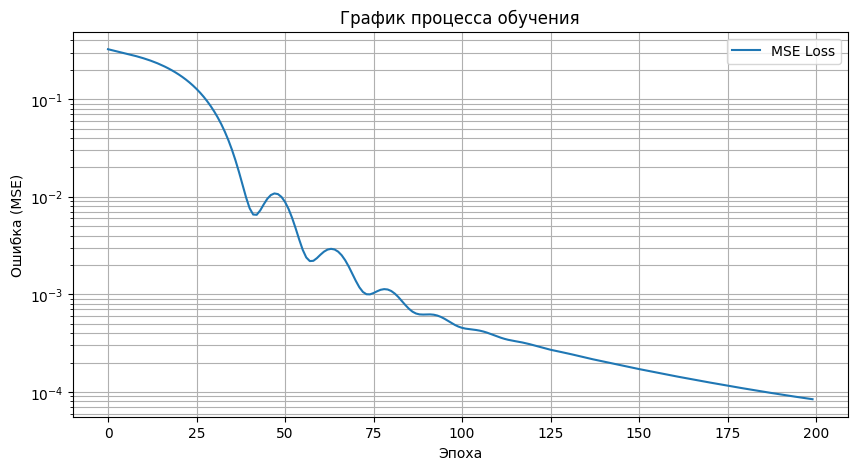

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(loss_history, label='MSE Loss')

plt.yscale('log')

plt.xlabel('Эпоха')
plt.ylabel('Ошибка (MSE)')

plt.title('График процесса обучения')

plt.legend()

plt.grid(True, which="both", ls="-")

plt.show()

Из графика видно, что ошибка постепенно уменьшается и выходит на плато. Это означает, что сеть успешно обучилась и дальнейшее увеличение числа эпох существенно не улучшит качество модели.

Теперь проверим работу модели на новых данных, которые не использовались при обучении.

In [ ]:
model.eval()

# Случайная тестовая точка
x_test_raw = np.random.uniform(-0.5, 0.5, size=(input_dim,))

x_test_tensor = torch.tensor(
    x_test_raw,
    dtype=torch.float32
).to(device)

# Истинное решение системы
t_eval = [i * T for i in range(1, N + 1)]

sol_test = solve_ivp(
    system_dynamics,
    [0, N * T],
    x_test_raw,
    t_eval=t_eval
)

y_true = sol_test.y.T

# Предсказание сети
with torch.no_grad():

    y_pred_raw = model(x_test_tensor).cpu().numpy()

    y_pred = y_pred_raw.reshape(N, input_dim)

Построим:

* график изменения $x_1(t)$;
* график изменения $x_2(t)$;
* общую фазовую траекторию.

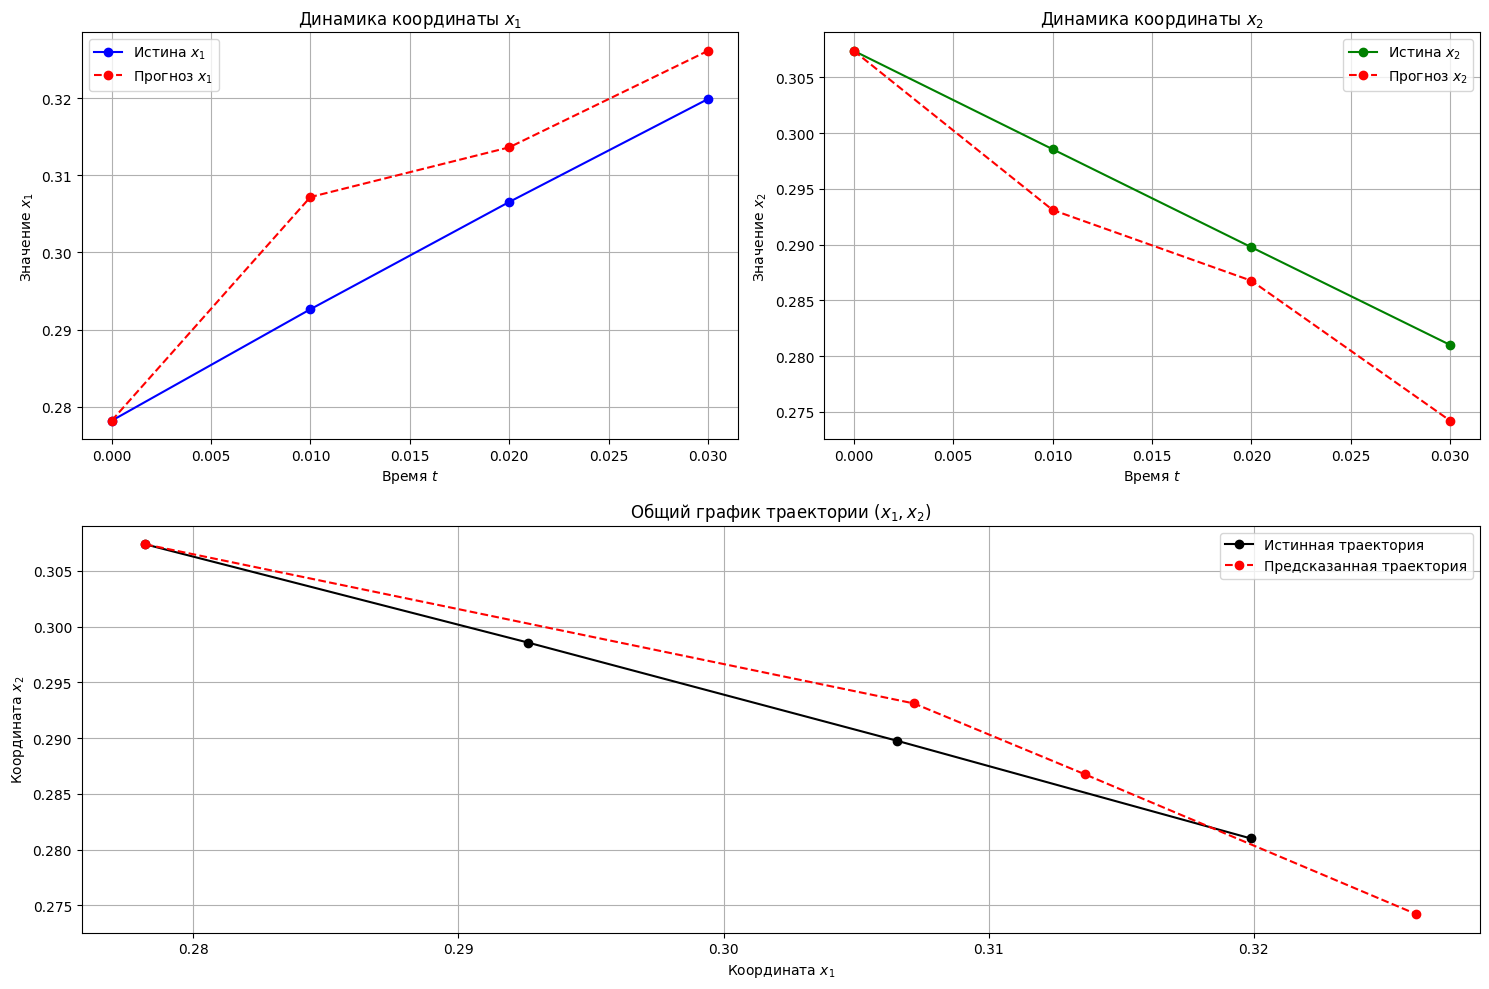

In [ ]:
time_axis = [i * T for i in range(N + 1)]

true_path_x1 = np.insert(y_true[:, 0], 0, x_test_raw[0])
true_path_x2 = np.insert(y_true[:, 1], 0, x_test_raw[1])

pred_path_x1 = np.insert(y_pred[:, 0], 0, x_test_raw[0])
pred_path_x2 = np.insert(y_pred[:, 1], 0, x_test_raw[1])

fig = plt.figure(figsize=(15, 10))

# График x1(t)
plt.subplot(2, 2, 1)

plt.plot(
    time_axis,
    true_path_x1,
    'bo-',
    label='Истина $x_1$'
)

plt.plot(
    time_axis,
    pred_path_x1,
    'r--o',
    label='Прогноз $x_1$'
)

plt.xlabel('Время $t$')
plt.ylabel('Значение $x_1$')

plt.title('Динамика координаты $x_1$')

plt.legend()

plt.grid(True)

# График x2(t)
plt.subplot(2, 2, 2)

plt.plot(
    time_axis,
    true_path_x2,
    'go-',
    label='Истина $x_2$'
)

plt.plot(
    time_axis,
    pred_path_x2,
    'r--o',
    label='Прогноз $x_2$'
)

plt.xlabel('Время $t$')
plt.ylabel('Значение $x_2$')

plt.title('Динамика координаты $x_2$')

plt.legend()

plt.grid(True)

# Общая траектория
plt.subplot(2, 1, 2)

plt.plot(
    true_path_x1,
    true_path_x2,
    'ko-',
    label='Истинная траектория'
)

plt.plot(
    pred_path_x1,
    pred_path_x2,
    'r--o',
    label='Предсказанная траектория'
)

plt.xlabel('Координата $x_1$')
plt.ylabel('Координата $x_2$')

plt.title('Общий график траектории $(x_1, x_2)$')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

Из графиков видно, что предсказания модели отличаются от реальных значений, но это скорее в силу того, что масштаб графика очень мал. Пэтому можно сделать вывод о том, что после обучения модель показала хорошее совпадение предсказанных значений с истинными траекториями системы.